## PART D: Random Forest
**Importing Python Libraries**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from collections import Counter

**The Decision Tree**

In [7]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left_child=None, right_child=None, label_value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left_child = left_child
        self.right_child = right_child
        self.label_value = label_value
        
    def is_leaf_node(self):
        return self.label_value is not None


class DecisionTreeClassifier:
    def __init__(self, min_samples_split=2, max_depth=100, max_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_importances_ = None  

    def fit(self, X, y):  
        self.n_features_ = X.shape[1]
        self.feature_importances_ = np.zeros(self.n_features_)
        self.root = self.build_tree(X, y, depth=0)
        
        if self.feature_importances_.sum() > 0:
            self.feature_importances_ /= self.feature_importances_.sum()
        
    # -----------------------------
    # Entropy + Info Gain
    # -----------------------------
    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return -np.sum(p * np.log2(p + 1e-9))
    
    def information_gain(self, y, y_left, y_right):
        if len(y_left) == 0 or len(y_right) == 0:
            return 0
        
        H_parent = self.entropy(y)
        H_left   = self.entropy(y_left)
        H_right  = self.entropy(y_right)
    
        w_left = len(y_left) / len(y)
        w_right = len(y_right) / len(y)
        
        return H_parent - (w_left * H_left + w_right * H_right)

    def majority_class(self, y):
        return Counter(y).most_common(1)[0][0]

    # -----------------------------
    # Best Split
    # -----------------------------
    def best_split(self, X, y):
        best_IG = -1
        best_feature_index = None
        best_threshold = None
    
        # Feature subsampling for RF
        if self.max_features is None:
            features = range(X.shape[1])
        else:
            features = np.random.choice(X.shape[1], self.max_features, replace=False)
    
        for feature_index in features:
            feature_values = np.sort(np.unique(X[:, feature_index]))
            if len(feature_values) < 2:
                continue
            
            thresholds = (feature_values[:-1] + feature_values[1:]) / 2
        
            for threshold in thresholds:
                left_bool = X[:, feature_index] <= threshold
                right_bool = X[:, feature_index] > threshold
                
                y_left  = y[left_bool]
                y_right = y[right_bool]
                
                info_gain = self.information_gain(y, y_left, y_right)
                
                if info_gain > best_IG:
                    best_IG = info_gain
                    best_feature_index = feature_index
                    best_threshold = threshold
    
        return best_feature_index, best_threshold, best_IG 

    # -----------------------------
    # Build Tree Recursively
    # -----------------------------
    def build_tree(self, X, y, depth=0):
        if len(np.unique(y)) == 1:
            return Node(label_value=y[0])
        
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return Node(label_value=self.majority_class(y))
        
        feature_index, threshold, ig = self.best_split(X, y)
        if feature_index is None or ig <= 0:
            return Node(label_value=self.majority_class(y))

        self.feature_importances_[feature_index] += ig * len(y)

        left_bool  = X[:, feature_index] <= threshold
        right_bool = X[:, feature_index] > threshold
        
        left_child  = self.build_tree(X[left_bool],  y[left_bool],  depth + 1)
        right_child = self.build_tree(X[right_bool], y[right_bool], depth + 1)

        return Node(
            feature_index=feature_index,
            threshold=threshold,
            left_child=left_child,
            right_child=right_child
        )

    # -----------------------------
    # Prediction
    # -----------------------------
    def predict_single_sample(self, node, x):
        if node.label_value is not None:
            return node.label_value
        
        if x[node.feature_index] <= node.threshold:
            return self.predict_single_sample(node.left_child, x)
        else:
            return self.predict_single_sample(node.right_child, x)
        
    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_single_sample(self.root, x) for x in X])


**Load Dataset +    Train/Validation/Test Split**

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/(1-0.15), random_state=42, stratify=y_temp
)

print("Classes:", data.target_names)

Classes: ['malignant' 'benign']


**Hyperparameter Tuning (Decision Tree)**

In [9]:
max_depth_values = [2, 4, 6, 8, 10]
min_samples_split_values = [2, 5, 10]

results = []

for depth in max_depth_values:
    for min_s in min_samples_split_values:
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_split=min_s)
        tree.fit(X_train, y_train)
        val_pred = tree.predict(X_val)
        acc = accuracy_score(y_val, val_pred)
        results.append((depth, min_s, acc))

tuning_df = pd.DataFrame(results, columns=["max_depth","min_samples_split","val_accuracy"])
print(tuning_df)

    max_depth  min_samples_split  val_accuracy
0           2                  2      0.930233
1           2                  5      0.930233
2           2                 10      0.930233
3           4                  2      0.965116
4           4                  5      0.965116
5           4                 10      0.976744
6           6                  2      0.965116
7           6                  5      0.965116
8           6                 10      0.976744
9           8                  2      0.965116
10          8                  5      0.965116
11          8                 10      0.976744
12         10                  2      0.965116
13         10                  5      0.965116
14         10                 10      0.976744


**Find best hyperparameters**

In [10]:
best_idx = tuning_df['val_accuracy'].idxmax()
best_depth = tuning_df.loc[best_idx, 'max_depth']
best_min_samples = tuning_df.loc[best_idx, 'min_samples_split']
best_acc = tuning_df.loc[best_idx, 'val_accuracy']
print(f"Best Decision Tree → depth={best_depth}, min_samples_split={best_min_samples}, val_acc={best_acc:.4f}")

Best Decision Tree → depth=4, min_samples_split=10, val_acc=0.9767


**Retrain final Decision Tree on train+val**

In [11]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
best_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_min_samples)
best_tree.fit(X_trainval, y_trainval)
y_pred_test = best_tree.predict(X_test)
print("DT Test Accuracy =", accuracy_score(y_test, y_pred_test))

DT Test Accuracy = 0.9418604651162791


# **RANDOM FOREST IMPLEMENTATION**

In [12]:
class RandomForest:
    def __init__(self, n_trees, max_features, max_depth, min_samples_split):
        self.n_trees = n_trees
        self.max_features = max_features
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
    def bootstrap_sample(self, X, y):
        n = X.shape[0]
        idx = np.random.choice(n, n, replace=True)
        return X[idx], y[idx]
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            X_s, y_s = self.bootstrap_sample(X, y)
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_s, y_s)
            self.trees.append(tree)
    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])  # shape: (T, N)
        final = []
        for i in preds.T:
            final.append(Counter(i).most_common(1)[0][0])
        return np.array(final)

**Hyperparameter tuning for Random Forest**

In [13]:
d = X_train.shape[1]
feature_options = [int(np.sqrt(d)), int(d/2)]
T_values = [5, 10, 30, 50]
rf_results = []
for T in T_values:
    for mf in feature_options:
        rf = RandomForest(
            n_trees=T,
            max_features=mf,
            max_depth=best_depth,
            min_samples_split=best_min_samples
        )
        rf.fit(X_train, y_train)
        pred = rf.predict(X_val)
        acc = accuracy_score(y_val, pred)
        rf_results.append((T, mf, acc))
rf_df = pd.DataFrame(rf_results, columns=["Trees", "max_features", "val_accuracy"])
print(rf_df)

   Trees  max_features  val_accuracy
0      5             5      0.953488
1      5            15      0.953488
2     10             5      0.965116
3     10            15      0.976744
4     30             5      0.976744
5     30            15      0.976744
6     50             5      0.976744
7     50            15      0.976744


**Best RandomForest model**

In [14]:
idx = rf_df['val_accuracy'].idxmax()
best_T = rf_df.loc[idx, 'Trees']
best_mf = rf_df.loc[idx, 'max_features']
best_rf_acc = rf_df.loc[idx, 'val_accuracy']
print(f"Best RF → Trees={best_T}, max_features={best_mf}, val_acc={best_rf_acc:.4f}")

Best RF → Trees=10, max_features=15, val_acc=0.9767


**Train final RandomForest on train+val and evaluate on test**

In [15]:
final_rf = RandomForest(
    n_trees=best_T,
    max_features=best_mf,
    max_depth=best_depth,
    min_samples_split=best_min_samples
)
final_rf.fit(X_trainval, y_trainval)
rf_test_pred = final_rf.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
print("Final Random Forest Test Accuracy =", rf_test_acc)

Final Random Forest Test Accuracy = 0.9418604651162791


**Confusion matrix for RF**

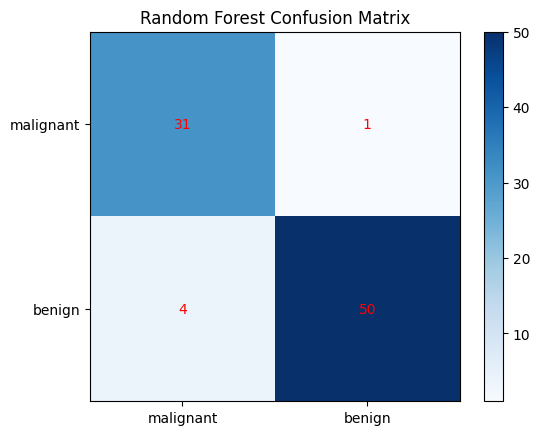

In [16]:
cm = confusion_matrix(y_test, rf_test_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], data.target_names)
plt.yticks([0,1], data.target_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='red')
plt.show()

## COMPARISON BETWEEN DECISION TREES AND RANDOM FOREST
A **decision tree** is a high-variance, low-bias model (can fit complex decision boundaries) that recursively splits the feature space into regions.
Key properties:
- Sensitive to training noise or small changes in data→ high variance
- Tends to overfit unless depth is limited
- Easy to interpret

A **random forest** is an ensemble of many decision trees trained on:
- Bootstrap samples (bagging)
- Random subsets of features at each split
This reduces:
- Bias increases slightly, because each tree sees less information
- Variance (trees disagree, so errors average out)
- Overfitting (randomness decorrelates trees)

1. Accuracy: The random forest accuracy is 0.9419 and the decision tree accuracy is 0.9419, meaning both in this case are equal.
2. In both cases looking at the confusion matrix 5 samples were misclassified.

Normally, a RandomForest should **outperform** the Decision Tree, which is not the case here.
This is due to multiple reasons:
- Our dataset is somewha stable with low noise
- As we tuned the hyperparameters, the decision tree chosen was optimal
Random Forest did not improve performance because the Decision Tree was already low-variance and the dataset is small and well-behaved.